In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [3]:
df = pd.read_csv("../week 2/processed_student_dataset.csv")

df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,average_score,assessment_count,total_clicks,avg_clicks
0,0,1,11391,1,0,1,9,2,0.0,0.336,0,2,0.820,0.178571,0.032640,0.245286
1,0,1,28400,0,6,1,2,1,0.0,0.048,0,2,0.664,0.178571,0.050149,0.171777
2,0,1,30268,0,5,0,3,1,0.0,0.048,1,3,0.000,0.000000,0.009820,0.190316
3,0,1,31604,0,7,0,5,1,0.0,0.048,0,2,0.760,0.178571,0.075415,0.167541
4,0,1,32885,0,11,2,5,0,0.0,0.048,0,2,0.544,0.178571,0.036135,0.151203


In [4]:
X = df.drop("final_result", axis=1)
y = df["final_result"]

print(X.shape)
print(y.shape)

(32593, 15)
(32593,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [7]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

              Feature  Importance
12   assessment_count    0.199322
11      average_score    0.182005
13       total_clicks    0.130518
14         avg_clicks    0.101552
2          id_student    0.086219
4              region    0.054213
0         code_module    0.052566
6            imd_band    0.050188
9     studied_credits    0.036026
1   code_presentation    0.033923


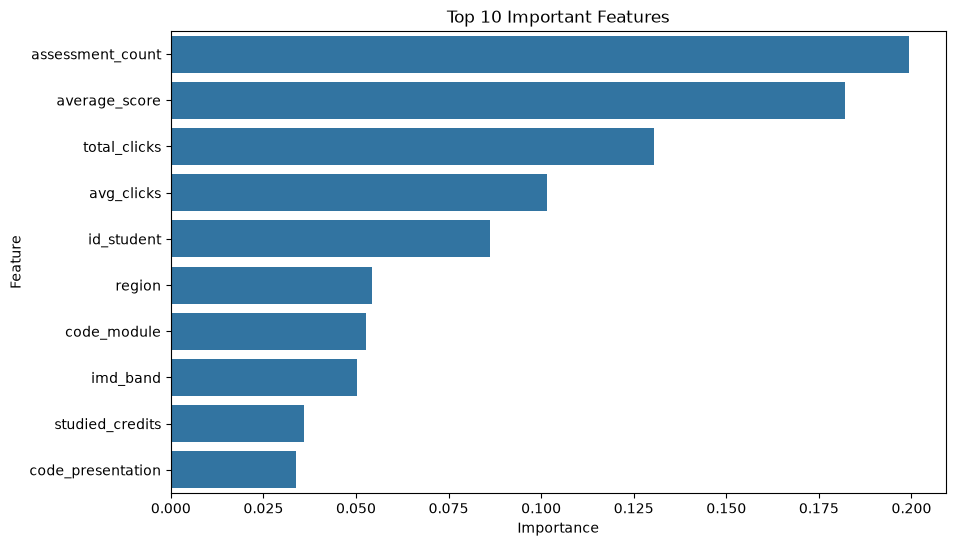

In [8]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

In [9]:
result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
})

perm = perm.sort_values(
    by="Importance",
    ascending=False
)

print(perm.head(10))

                 Feature  Importance
12      assessment_count    0.207762
11         average_score    0.104326
0            code_module    0.042123
13          total_clicks    0.025357
1      code_presentation    0.012594
9        studied_credits    0.007363
8   num_of_prev_attempts    0.004080
14            avg_clicks    0.003896
5      highest_education    0.002899
10            disability    0.002270


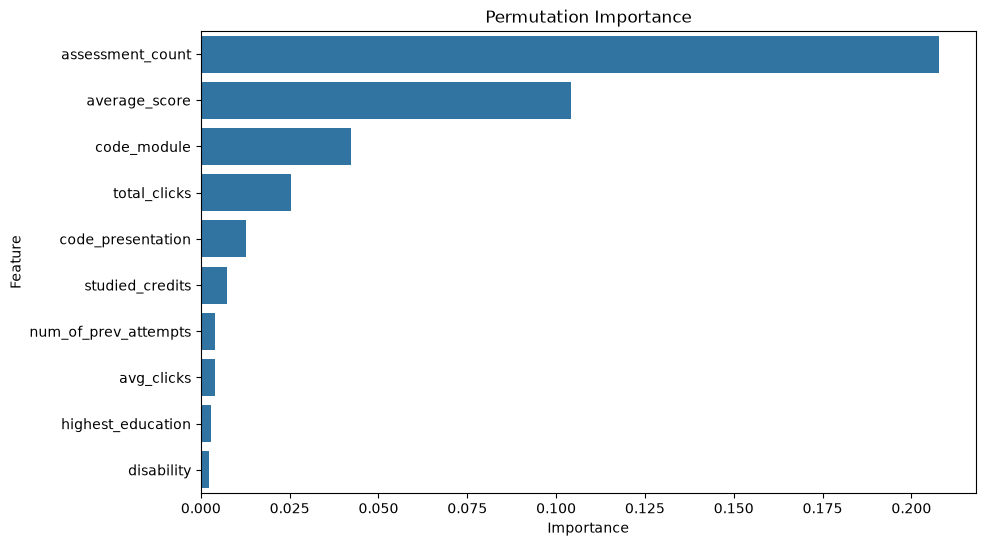

In [10]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=perm.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Permutation Importance")
plt.show()

In [11]:
print("""
Most influential features:

1. assessment_count
2. average_score
3. total_clicks
4. avg_clicks

These variables have the strongest impact on student outcome prediction.
""")


Most influential features:

1. assessment_count
2. average_score
3. total_clicks
4. avg_clicks

These variables have the strongest impact on student outcome prediction.



In [15]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.6826200337475072


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.45      0.51       593
           1       0.60      0.34      0.43      1495
           2       0.70      0.90      0.78      2458
           3       0.71      0.75      0.73      1973

    accuracy                           0.68      6519
   macro avg       0.65      0.61      0.62      6519
weighted avg       0.67      0.68      0.66      6519



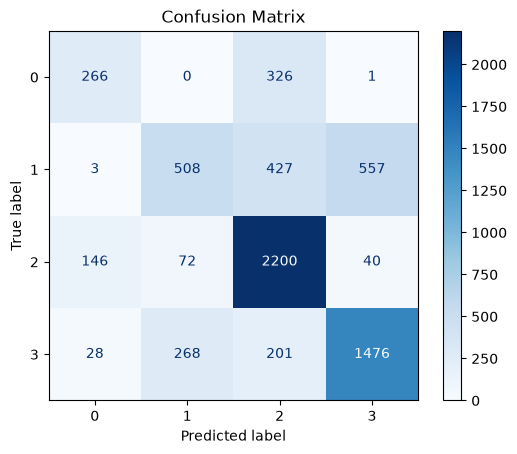

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

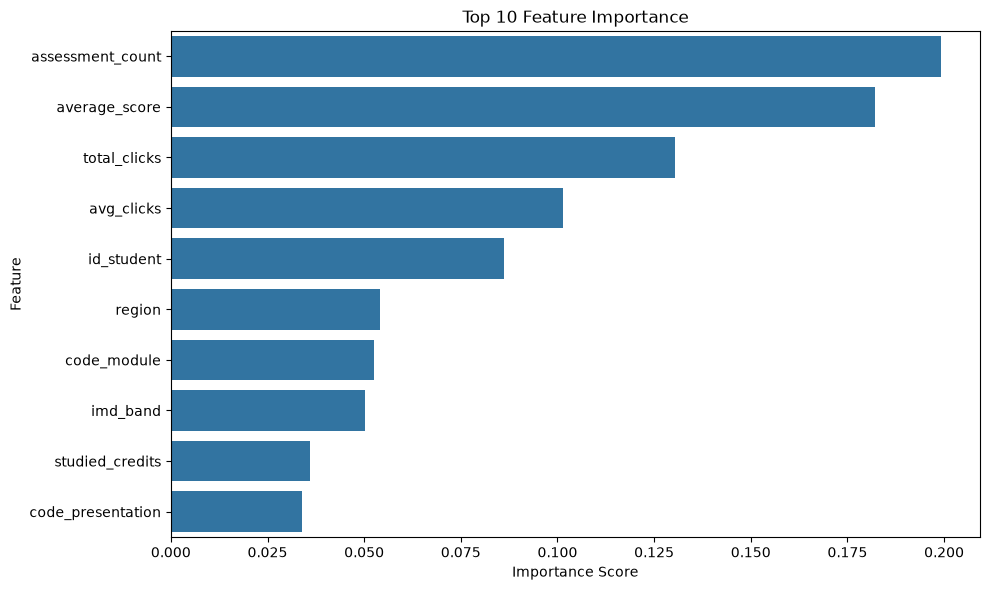

In [18]:
plt.figure(figsize=(10,6))

top_features = importance.head(10)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

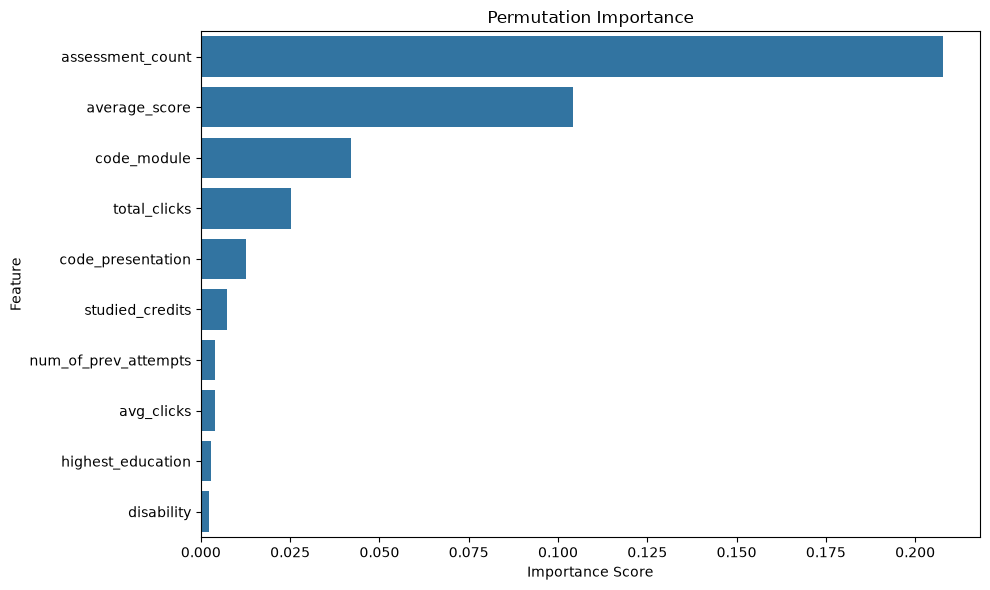

In [19]:
plt.figure(figsize=(10,6))

top_perm = perm.head(10)

sns.barplot(
    data=top_perm,
    x="Importance",
    y="Feature"
)

plt.title("Permutation Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [20]:
print("Top Features Influencing Predictions:")

print(importance.head(10))

Top Features Influencing Predictions:
              Feature  Importance
12   assessment_count    0.199322
11      average_score    0.182005
13       total_clicks    0.130518
14         avg_clicks    0.101552
2          id_student    0.086219
4              region    0.054213
0         code_module    0.052566
6            imd_band    0.050188
9     studied_credits    0.036026
1   code_presentation    0.033923


In [21]:
sample_student = X_test.iloc[[0]]

prediction = model.predict(sample_student)

print("Predicted Class:", prediction)

Predicted Class: [2]


In [22]:
print("""
Interpretation Summary

1. Assessment Count is the most influential feature.

2. Average Score strongly affects prediction.

3. Student engagement measured through total clicks
   contributes significantly.

4. Students with higher engagement and assessment
   performance are more likely to achieve positive outcomes.

5. Explainable AI improves transparency and trust
   in educational prediction systems.
""")


Interpretation Summary

1. Assessment Count is the most influential feature.

2. Average Score strongly affects prediction.

3. Student engagement measured through total clicks
   contributes significantly.

4. Students with higher engagement and assessment
   performance are more likely to achieve positive outcomes.

5. Explainable AI improves transparency and trust
   in educational prediction systems.

